In [ ]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 79.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=4e581e0ee28572cfba30c3350f1cffa952894b2176732cf3d22c6abed73fe1e8
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


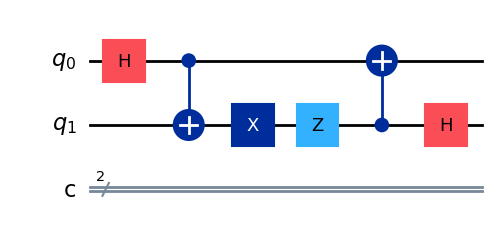

In [ ]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2,2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing

# For 01, apply X to qubit 1
#sdc.x(1)

# For 10, apply Z to qubit 1
#sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [ ]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

/usr/local/lib/python3.12/dist-packages/qiskit_aer/noise/noise_model.py:378: UserWarning: Qiskit backend <qiskit.providers.fake_provider.generic_backend_v2.GenericBackendV2 object at 0x789640a43080> has no QubitProperties, so the resulting noise model will not include any thermal relaxation errors.
  warn(


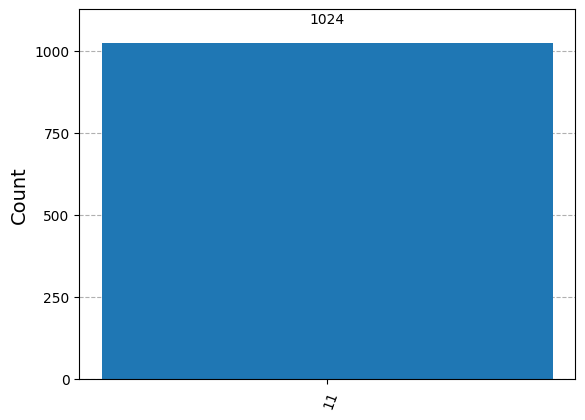

In [20]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

sdc.measure([0,1],[0,1])

backend = GenericBackendV2(num_qubits=2,control_flow=True,noise_info=False)
compiled = transpile(sdc, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts,indices=[0,1])
plot_histogram(counts)

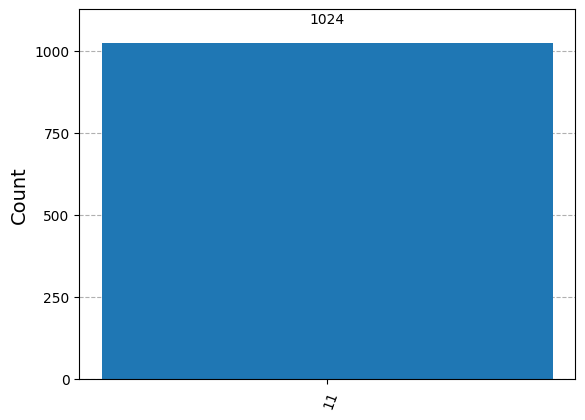

In [22]:
backend = BasicSimulator()
compiled = transpile(sdc, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts,indices=[0,1])
plot_histogram(counts)